In [77]:
("Siddhant Dethe")

'Siddhant Dethe'

In [78]:
("Task 4 - MOVIE RATING PREDICTION WITH PYTHON")

'Task 4 - MOVIE RATING PREDICTION WITH PYTHON'

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("IMDb Movies India.csv", encoding='latin1')

In [3]:
data.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),-2019.0,109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,-2021.0,90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,-2019.0,110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,-2010.0,105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  float64
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(2), object(8)
memory usage: 1.2+ MB


In [5]:
data.describe()

,Year,Rating
count,14981.000000,7919.000000
mean,-1987.012215,5.841621
std,25.416689,1.381777
min,-2022.000000,1.100000
25%,-2009.000000,4.900000
50%,-1991.000000,6.000000
75%,-1968.000000,6.800000
max,-1913.000000,10.000000


In [6]:
data.isnull().sum()

Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64

In [7]:
data.drop(['Name'], axis = 1, inplace = True)

In [8]:
data.dropna(inplace = True)

In [9]:
data.isnull().sum()

Year        0
Duration    0
Genre       0
Rating      0
Votes       0
Director    0
Actor 1     0
Actor 2     0
Actor 3     0
dtype: int64

In [10]:
data.shape

(5659, 9)

In [11]:
data.columns

Index(['Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director', 'Actor 1',
       'Actor 2', 'Actor 3'],
      dtype='object')

In [17]:
data['Year'] = pd.to_numeric(data['Year'].astype(str).str.replace(r'[()]', '', regex = True), errors='coerce').astype(int)

In [18]:
data['Duration'] = pd.to_numeric(data['Duration'].str.replace('min', ''))

In [19]:
data['Genre'] = data['Genre'].str.split(', ')
data = data.explode('Genre')
data['Genre'].fillna(data['Genre'].mode()[0], inplace = True)

C:\Users\Siddhant Dethe\AppData\Local\Temp\ipykernel_23416\3446330567.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Genre'].fillna(data['Genre'].mode()[0], inplace = True)


In [20]:
data['Votes'] = pd.to_numeric(data['Votes'].str.replace(',', ''))

In [21]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11979 entries, 1 to 15508
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Year      11979 non-null  int64  
 1   Duration  11979 non-null  int64  
 2   Genre     11979 non-null  object 
 3   Rating    11979 non-null  float64
 4   Votes     11979 non-null  int64  
 5   Director  11979 non-null  object 
 6   Actor 1   11979 non-null  object 
 7   Actor 2   11979 non-null  object 
 8   Actor 3   11979 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 935.9+ KB


<Axes: xlabel='Year', ylabel='Count'>

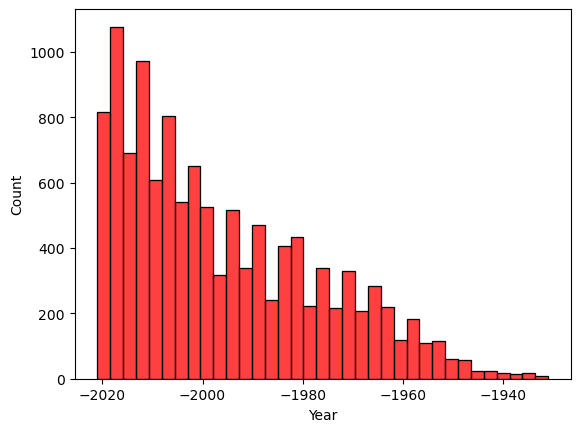

In [54]:
sns.histplot(x = 'Year', data = data, color = 'red')

In [36]:
from sklearn.preprocessing import LabelEncoder

In [39]:
le = LabelEncoder()

data['Genre'] = le.fit_transform(data['Genre'])
data['Director'] = le.fit_transform(data['Director'])
data['Actor 1'] = le.fit_transform(data['Actor 1'])
data['Actor 2'] = le.fit_transform(data['Actor 2'])
data['Actor 3'] = le.fit_transform(data['Actor 3'])

In [40]:
from sklearn.model_selection import train_test_split

In [42]:
x = data.drop('Rating', axis = 1)
y = data['Rating']

In [43]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [56]:
print("Train Data:", x_train)
print("\nTest Data:", x_test)

Train Data:        Year  Duration  Genre  Votes  Director  Actor 1  Actor 2  Actor 3
6013  -2010       131      4     38      2157     1754      672     1241
4245  -1979       139      0     78      2259     1587     1641     1396
12042 -2020       152      0      8       556     1110     1273     1102
9488  -2011       124      3     72      2200      287      521     1686
9267  -2003       110      0      7       943     1565      143     1955
...     ...       ...    ...    ...       ...      ...      ...      ...
6087  -1935       144      7     38       486      507     1433     2307
8821  -2005       150      3   9520       981       15     1585     2354
36    -2004        94      7     16      2099     1793      625     2478
1513  -2018        48      7    271      2257      153     2106     2332
2035  -1994       166      7     44       751     1238     1886      869

[9583 rows x 8 columns]

Test Data:        Year  Duration  Genre  Votes  Director  Actor 1  Actor 2  Actor 3
83

In [50]:
from sklearn.ensemble import RandomForestRegressor

In [52]:
model = RandomForestRegressor(n_estimators = 100, random_state = 42)
model.fit(x_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [57]:
y_pred = model.predict(x_test)
print(y_pred)

[4.263 5.581 6.591 ... 3.667 8.268 6.105]


In [61]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [62]:
# mean_absolut_error close to 0 → Good
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 0.4377132721202002


In [63]:
# RMSE low → Good
rmse = np.sqrt(mean_absolute_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 0.6615990266923012


In [64]:
# R² close to 1 → Excellent
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.7567835756693548


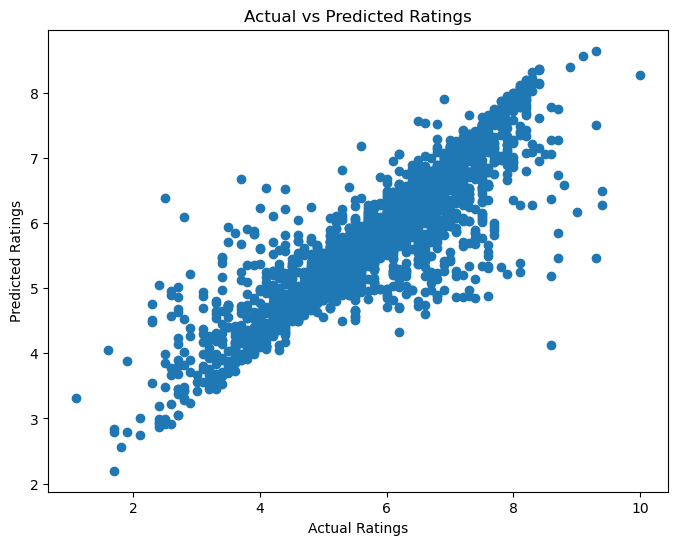

In [72]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Actual vs Predicted Ratings")
plt.show()

In [74]:
importance = model.feature_importances_

feature_names = x.columns

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nFeature Importance:\n")

print(feature_importance)



Feature Importance:

    Feature  Importance
3     Votes    0.266594
0      Year    0.218081
5   Actor 1    0.103917
1  Duration    0.103880
6   Actor 2    0.095547
7   Actor 3    0.094128
4  Director    0.089334
2     Genre    0.028519


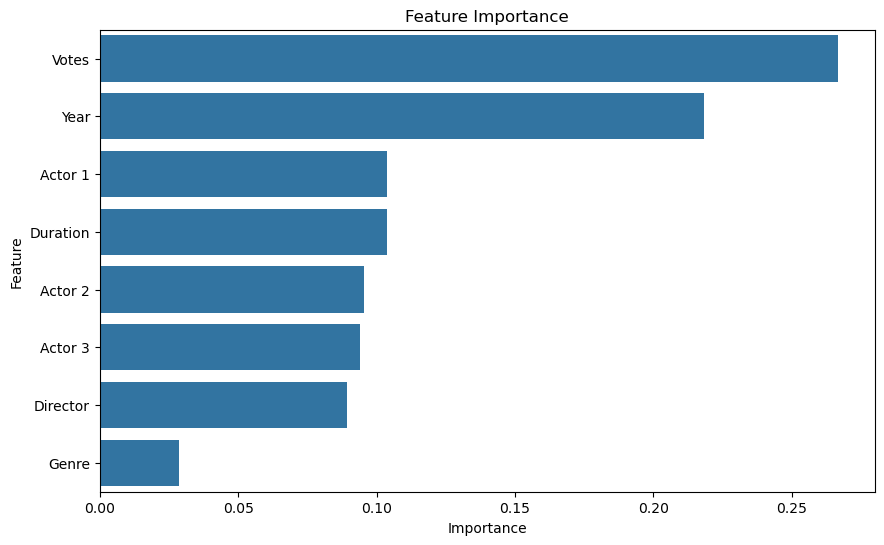

In [75]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Feature Importance")

plt.show()

In [76]:
comparison = pd.DataFrame({
    'Actual Rating': y_test.values,
    'Predicted Rating': y_pred
})

print("\nSample Predictions:\n")

print(comparison.head(10))



Sample Predictions:

   Actual Rating  Predicted Rating
0            3.6             4.263
1            5.8             5.581
2            6.6             6.591
3            6.1             5.799
4            7.5             7.438
5            6.0             5.600
6            6.2             6.052
7            4.2             4.427
8            7.4             7.005
9            6.3             6.340
